In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE

In [3]:
file_path="BNBFDUSD_20250314.txt"
df_order_book= pd.read_csv(file_path)
trade_path="BNBFDUSD_20250314_trade.txt"
df_trade = pd.read_csv(trade_path)

In [4]:
def clean_and_parse_time(col):
    return pd.to_datetime(col.str.replace(' IST', ''), utc=True)

df_order_book['Time'] = clean_and_parse_time(df_order_book['Time'])
df_trade['Time'] = clean_and_parse_time(df_trade['Time'])

In [5]:
df=df_order_book.merge(df_trade, on='Time', how='outer')
#add a column type
df['Type'] = df['Price'].apply(lambda x: 'Trade' if pd.notnull(x) else 'Quote')
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col]=df[col].ffill()

In [6]:
df.columns

Index(['Time', 'BidPriceL20', 'BidQtyL20', 'BidPriceL19', 'BidQtyL19',
       'BidPriceL18', 'BidQtyL18', 'BidPriceL17', 'BidQtyL17', 'BidPriceL16',
       'BidQtyL16', 'BidPriceL15', 'BidQtyL15', 'BidPriceL14', 'BidQtyL14',
       'BidPriceL13', 'BidQtyL13', 'BidPriceL12', 'BidQtyL12', 'BidPriceL11',
       'BidQtyL11', 'BidPriceL10', 'BidQtyL10', 'BidPriceL9', 'BidQtyL9',
       'BidPriceL8', 'BidQtyL8', 'BidPriceL7', 'BidQtyL7', 'BidPriceL6',
       'BidQtyL6', 'BidPriceL5', 'BidQtyL5', 'BidPriceL4', 'BidQtyL4',
       'BidPriceL3', 'BidQtyL3', 'BidPriceL2', 'BidQtyL2', 'BidPriceL1',
       'BidQtyL1', 'AskPriceL1', 'AskQtyL1', 'AskPriceL2', 'AskQtyL2',
       'AskPriceL3', 'AskQtyL3', 'AskPriceL4', 'AskQtyL4', 'AskPriceL5',
       'AskQtyL5', 'AskPriceL6', 'AskQtyL6', 'AskPriceL7', 'AskQtyL7',
       'AskPriceL8', 'AskQtyL8', 'AskPriceL9', 'AskQtyL9', 'AskPriceL10',
       'AskQtyL10', 'AskPriceL11', 'AskQtyL11', 'AskPriceL12', 'AskQtyL12',
       'AskPriceL13', 'AskQtyL13', 'AskPr

In [7]:
df['mid_price'] = (df['BidPriceL1'] + df['AskPriceL1']) / 2

# 1. Trend Features
df['mid_price_return'] = np.log(df['mid_price'] / df['mid_price'].shift(1))
df['rolling_return_std_30s'] = df['mid_price_return'].rolling(window=30).std()
df['price_autocorr_30s'] = df['mid_price_return'].rolling(window=30).apply(lambda x: x.autocorr(), raw=False)
df['momentum_5s'] = df['mid_price'] - df['mid_price'].shift(5)

vwap = (df['Price'] * df['Quantity']).cumsum() / df['Quantity'].cumsum()
df['vwap_shift_10s'] = vwap - vwap.shift(10)

df['microprice'] = (df['BidPriceL1'] * df['AskQtyL1'] + df['AskPriceL1'] * df['BidQtyL1']) / (df['BidQtyL1'] + df['AskQtyL1'])
df['microprice_return'] = np.log(df['microprice'] / df['microprice'].shift(1))

features_trend = [
    'mid_price', 'mid_price_return', 'rolling_return_std_30s', 'price_autocorr_30s',
    'momentum_5s', 'vwap_shift_10s', 'microprice_return'
]

# 2. Volatility Features
df['rolling_return_std_10s'] = df['mid_price_return'].rolling(window=10).std()
df['abs_price_change_10s'] = df['mid_price'].diff(10).abs()
df['price_range_30s'] = df['mid_price'].rolling(window=30).apply(lambda x: x.max() - x.min(), raw=True)
df['volume_spike_30s'] = df['Quantity'].rolling(window=30).sum()
df['vwap_std_30s'] = vwap.rolling(window=30).std()
df['bid_ask_spread_std_10s'] = df['spread'].rolling(window=10).std()

features_volatility = [
    'rolling_return_std_10s', 'rolling_return_std_30s', 'abs_price_change_10s',
    'price_range_30s', 'volume_spike_30s', 'vwap_std_30s', 'bid_ask_spread_std_10s'
]

# 3. Liquidity Features
df['cum_bid_qty'] = df[[f'BidQtyL{i}' for i in range(1, 21)]].sum(axis=1)
df['cum_ask_qty'] = df[[f'AskQtyL{i}' for i in range(1, 21)]].sum(axis=1)
df['order_book_imbalance_lvl1'] = (df['BidQtyL1'] - df['AskQtyL1']) / (df['BidQtyL1'] + df['AskQtyL1'])

df['num_trades_10s'] = df['NumTrades'].rolling(window=10).sum()
df['market_order_fraction'] = df['IsMarketMaker'].rolling(window=10).mean()
df['avg_trade_size_10s'] = df['Quantity'].rolling(window=10).mean()


features_liquidity = [
    'spread', 'cum_bid_qty', 'cum_ask_qty', 'order_book_imbalance_lvl1',
    'num_trades_10s', 'market_order_fraction', 'avg_trade_size_10s'
]

df_trend = df[features_trend].copy()
df_trend = df_trend.dropna()
df_volatility = df[features_volatility].copy()
df_volatility = df_volatility.dropna()
df_liquidity = df[features_liquidity].copy()
df_liquidity = df_liquidity.dropna()

KeyError: 'spread'

In [ ]:
df_trend.dropna(inplace=True)
df_volatility.dropna(inplace=True)
df_liquidity.dropna(inplace=True)
df_trend

,mid_price,mid_price_return,rolling_return_std_30s,price_autocorr_30s,momentum_5s,vwap_shift_10s,microprice_return
30,579.415,0.000000,0.000043,-0.016446,0.070,0.014352,0.000000
31,579.290,-0.000216,0.000058,-0.023820,-0.055,0.012247,-0.000194
32,579.290,0.000000,0.000058,-0.042910,-0.055,0.011226,0.000000
33,579.290,0.000000,0.000058,-0.029428,-0.125,0.010248,0.000000
34,579.290,0.000000,0.000053,-0.021063,-0.125,0.008958,0.000000
...,...,...,...,...,...,...,...
387690,585.730,0.000000,0.000014,-0.151437,0.005,0.000166,0.000000
387691,585.755,0.000043,0.000016,-0.124979,0.020,0.000182,0.000024
387692,585.745,-0.000017,0.000016,-0.206065,0.000,0.000198,-0.000006
387693,585.745,0.000000,0.000016,-0.201924,0.000,0.000187,0.000000


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def apply_pca(df_features, n_components=2):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features)
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    return X_pca, pca.explained_variance_ratio_

# Trend
df_trend = df[features_trend].dropna()
X_trend_pca, var_trend = apply_pca(df_trend)

# Volatility
df_volatility = df[features_volatility].dropna()
X_volatility_pca, var_vol = apply_pca(df_volatility)

# Liquidity
df_liquidity = df[features_liquidity].dropna()
X_liquidity_pca, var_liquidity = apply_pca(df_liquidity)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
df_trend_pca= pd.DataFrame(X_trend_pca, columns=['PC1', 'PC2'])
df_volatility_pca= pd.DataFrame(X_volatility_pca, columns=['PC1', 'PC2'])
df_liquidity_pca= pd.DataFrame(X_liquidity_pca, columns=['PC1', 'PC2'])

In [ ]:
def apply_clustering(df_pca, method='kmeans', max_k=10, fixed_k=4, plot_elbow=True):
    X = df_pca[['PC1', 'PC2']].values
    if method == 'kmeans':
        distortions = []
        for k in range(2, max_k + 1):
            kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
            distortions.append(kmeans.inertia_)
        if plot_elbow:
            plt.figure(figsize=(6, 4))
            plt.plot(range(2, max_k + 1), distortions, marker='o')
            plt.title('Elbow Method for Optimal K')
            plt.xlabel('Number of Clusters')
            plt.ylabel('Distortion (Inertia)')
            plt.grid()
            plt.show()
        
        kmeans = KMeans(n_clusters=fixed_k, random_state=42).fit(X)
        labels = kmeans.labels_
        #sil_score = silhouette_score(X, labels)
        #db_score = davies_bouldin_score(X, labels)

    elif method == 'gmm':
        gmm = GaussianMixture(n_components=fixed_k, random_state=42).fit(X)
        labels = gmm.predict(X)
        #sil_score = silhouette_score(X, labels)
        #db_score = davies_bouldin_score(X, labels)

    else:
        raise ValueError("Method must be 'kmeans' or 'gmm'.")

    df_labeled = df_pca.copy()
    df_labeled['Cluster'] = labels

    return df_labeled


In [ ]:
df_trend_clusters = apply_clustering(df_trend_pca, method='kmeans', fixed_k=3)
df_volatility_clusters = apply_clustering(df_volatility_pca, method='kmeans', fixed_k=3)
df_liquidity_clusters = apply_clustering(df_liquidity_pca, method='kmeans', fixed_k=3)

def plot_clusters(df_labeled, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_labeled, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=50)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster')
    plt.grid()
    plt.show()
def apply_tsne(df_features, n_components=2, perplexity=30):
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(df_features)
    return X_tsne
X_trend_tsne = apply_tsne(df_trend_pca[['PC1', 'PC2']])
X_volatility_tsne = apply_tsne(df_volatility_pca[['PC1', 'PC2']])
X_liquidity_tsne = apply_tsne(df_liquidity_pca[['PC1', 'PC2']])
df_trend_tsne = pd.DataFrame(X_trend_tsne, columns=['TSNE1', 'TSNE2'])
df_volatility_tsne = pd.DataFrame(X_volatility_tsne, columns=['TSNE1', 'TSNE2'])
df_liquidity_tsne = pd.DataFrame(X_liquidity_tsne, columns=['TSNE1', 'TSNE2'])
df_trend_tsne['Cluster'] = df_trend_clusters['Cluster']
df_volatility_tsne['Cluster'] = df_volatility_clusters['Cluster']
df_liquidity_tsne['Cluster'] = df_liquidity_clusters['Cluster']
def plot_tsne_clusters(df_tsne, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Cluster', palette='viridis', s=50)
    plt.title(title)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Cluster')
    plt.grid()
    plt.show()
plot_tsne_clusters(df_trend_tsne, 'Trend Features t-SNE Clustering')
plot_tsne_clusters(df_volatility_tsne, 'Volatility Features t-SNE Clustering')
plot_tsne_clusters(df_liquidity_tsne, 'Liquidity Features t-SNE Clustering')


NameError: name 'apply_clustering' is not defined

In [ ]:
results_trend_kmeans = perform_clustering(X_trend_pca, method='kmeans')
results_volatility_kmeans = perform_clustering(X_volatility_pca, method='kmeans')
results_liquidity_kmeans = perform_clustering(X_liquidity_pca, method='kmeans')

# results_trend_gmm = perform_clustering(X_trend_pca, method='gmm')
# results_volatility_gmm = perform_clustering(X_volatility_pca, method='gmm')
# results_liquidity_gmm = perform_clustering(X_liquidity_pca, method='gmm')

# Plotting the results


KeyboardInterrupt: 

In [ ]:
bid_qty_cols = [f'BidQtyL{i}' for i in range(1, 21)]
ask_qty_cols = [f'AskQtyL{i}' for i in range(1, 21)]
df['mid_price'] = (df['BidPriceL1'] + df['AskPriceL1'])/2
df['bid_ask_spread']= df['AskPriceL1'] - df['BidPriceL1']
df['bid_ask_spread_shift_10s'] = df['bid_ask_spread'].shift(10)
df['momentum_10s']=df['mid_price'].pct_change(periods=10)
df['vwap'] = (df['Price']*df['Quantity']).rolling(10).sum() / df['Quantity'].rolling(10).sum()
df['vwap_shift_10s'] = df['vwap'] - df['vwap'].shift(10)
df['rolling_corr_midprice_vwap'] = df['mid_price'].rolling(20).corr(df['vwap'])

features=['bid_ask_spread_shift_10s','momentum_10s','vwap_shift_10s','rolling_corr_midprice_vwap']
df_trend= df[trend_features]
df_trend
df_trend = df_trend.replace([np.inf, -np.inf], np.nan).dropna()
df_trend

,bid_ask_spread_shift_10s,momentum_10s,vwap_shift_10s,rolling_corr_midprice_vwap
29,0.07,0.000173,0.058040,0.554404
30,0.07,0.000173,0.056655,0.687403
31,0.07,-0.000043,0.050922,0.686913
32,0.07,-0.000043,0.052401,0.600070
33,0.09,-0.000095,0.042612,0.537232
...,...,...,...,...
387690,0.05,-0.000026,-0.036570,0.580239
387691,0.05,0.000017,-0.033304,0.448716
387692,0.05,0.000000,-0.030542,0.413003
387693,0.05,0.000000,-0.003678,0.386210


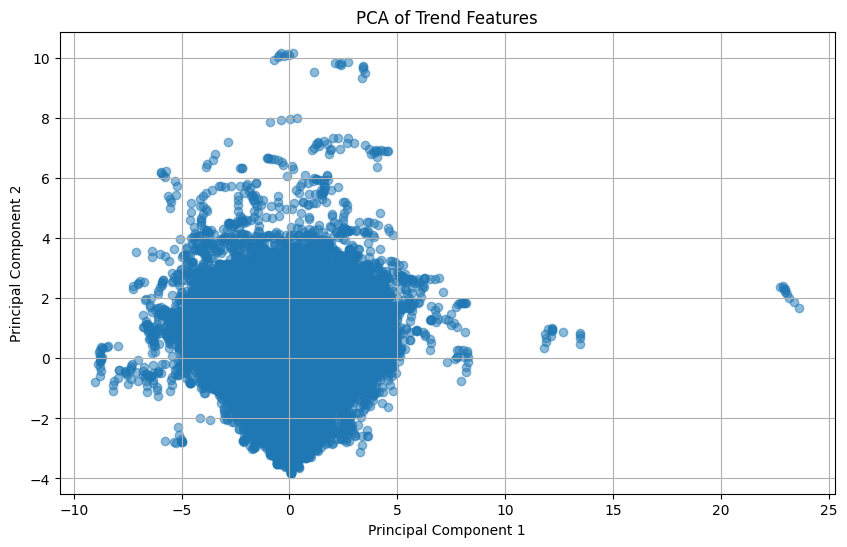

In [85]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_trend)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
plt.figure(figsize=(10, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5)
plt.title('PCA of Trend Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

C:\Users\choud\AppData\Local\Temp\ipykernel_20952\3622254122.py:11: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(K_range, inertia, 'bo-', marker='o')


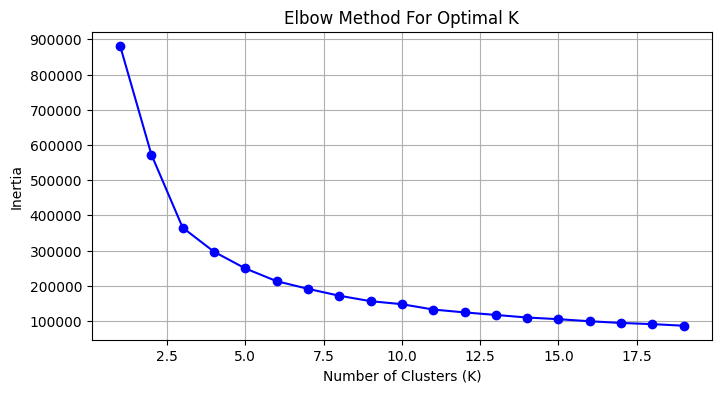

In [87]:
inertia = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  # You can use X_scaled or X_pca
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

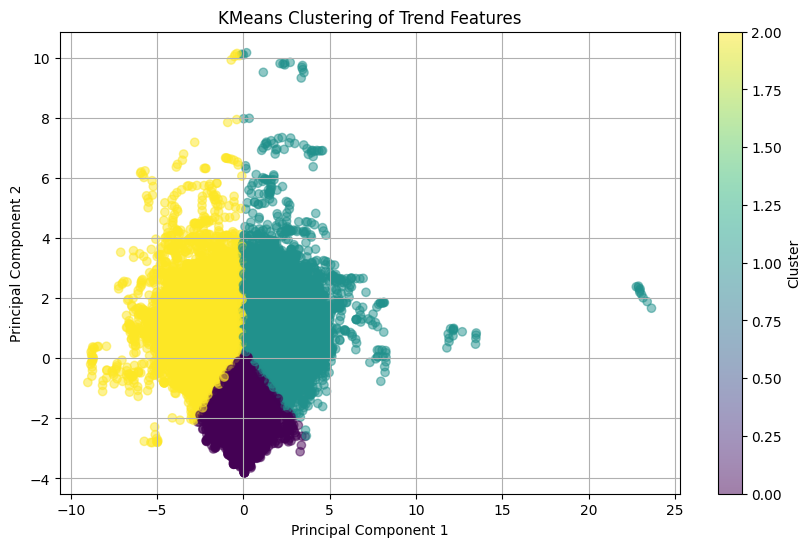

In [89]:
# Fit KMeans with the optimal number of clusters 3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_pca)
df_pca['Cluster'] = kmeans.labels_
plt.figure(figsize=(10, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='viridis', alpha=0.5)
plt.title('KMeans Clustering of Trend Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid()

In [97]:
from hmmlearn import hmm
df_hmm=df_pca.drop(columns=['Cluster'])
df_hmm

,PC1,PC2
0,1.579345,0.756358
1,1.563892,0.981038
2,0.301991,0.947076
3,0.318549,0.800481
4,-0.107798,1.317930
...,...,...
344123,-0.557012,0.118945
344124,-0.283539,-0.096539
344125,-0.347219,-0.158940
344126,-0.044813,-0.199038


Even though we used K-Means Clustering here but it is not generally used in a time-series data. K-Means usually considers data as i.i.d (independently identical distribution) so let us use HMM(Hidden Markov Models)

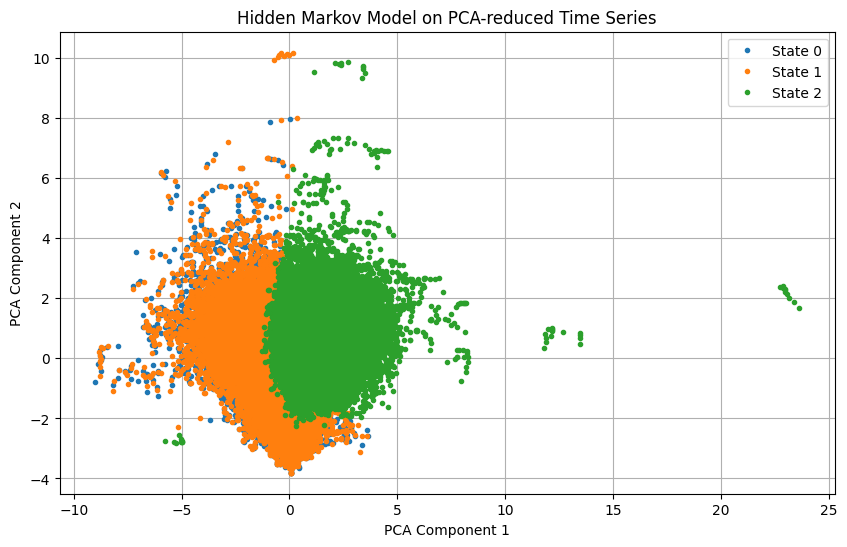

In [100]:
n_states = 3
model = hmm.GaussianHMM(n_components=n_states, covariance_type="full", n_iter=100)
model.fit(df_hmm)
hidden_states = model.predict(df_hmm)
plt.figure(figsize=(10, 6))
for i in range(n_states):
    plt.plot(
        df_hmm.loc[hidden_states == i].iloc[:, 0],  # X-axis
        df_hmm.loc[hidden_states == i].iloc[:, 1],  # Y-axis
        '.',
        label=f'State {i}'
    )
plt.title("Hidden Markov Model on PCA-reduced Time Series")
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()


